# Mitochondria 3D volume reconstruction Demo for EMCFsys papar in Fig5

Original full-size dataset:

1093 slice images with 2570 * 2495 size.

Volume size like: x * y * z = 2570 * 2495 * 1093, 20nm * 20nm * 10 nm

slice images from 3D volume named from q1_x01_y01_s0008 to q1_x01_y01_s1099.

Note that, train dataset was crop from q1_x01_y01_s0621.tif.

We crop 4 patches from q1_x01_y01_s0621.tif, and 2 patches for train, 1 patch for val and 1 patch for test.

train dataset: 2 patch with 626 mitochondria instances
    {
    "file_name": "patch_0_0.tif",
      "width": 1285,
      "height": 1247
    },
    {
      "file_name": "patch_1_1.tif",
      "width": 1285,
      "height": 1248
    }
 
 
val dataset: 1 patch with 322 mitochondria instances
    {
      "id": 3,
      "file_name": "patch_1_0.tif",
      "width": 1285,
      "height": 1248
    }


test dataset: 1 patch with 270 mitochondria instances
    {
      "id": 2,
      "file_name": "patch_0_1.tif",
      "width": 1285,
      "height": 1247
    }


Thus, the test data remains unseen by the model during training. Only a small fraction (1 out of 1091 slices) from the full 3D volume was selected to construct the train/val/test subsets, while the vast majority of slices were kept untouched for out‑of‑distribution evaluation. The training process takes approximately one hour.

In [ ]:
from pathlib import Path
import sys

import numpy as np
import torch
from PIL import Image

# Locate the repository whether Jupyter starts in the project root
BASE_DIR = Path.cwd().resolve().parent
sys.path.insert(0, str(BASE_DIR))

data_dir = (BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_MitoInstanceSegDataset")
import os
from huggingface_hub import snapshot_download

snapshot_download(repo_id="Zeyu0102/EMCFsys_MitoInstanceSegDataset", repo_type="dataset",
                  local_dir=data_dir,
                  local_dir_use_symlinks=False, 
                  resume_download=True)


c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\huggingface_hub\utils\_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [ ]:
from pathlib import Path
from mmengine import Config
from mmengine.runner import Runner
import sys

BASE_DIR = Path.cwd().resolve().parent
sys.path.insert(0, str(BASE_DIR))

cfg_path = (BASE_DIR / "src" / "thirdParty" / "mmdetection" / "configs" / "rtmdet" / "RTM_ins.py")
pretrained_model = (BASE_DIR / "models" / "MAE_backbone_mmbackend.pth")
work_dir = (BASE_DIR / "demo" / "logs" / "Mito_Instance")


cfg = Config.fromfile(str(cfg_path))
json_dir = (BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_MitoInstanceSegDataset")

cfg.data_root = str(json_dir)
for split, loader in (
    ("train", cfg.train_dataloader),
    ("val", cfg.val_dataloader),
    ("test", cfg.test_dataloader),
):
    loader.dataset.data_root = str(json_dir)
    loader.dataset.ann_file = f"{split}.json"

cfg.val_evaluator.ann_file = str(json_dir / "val.json")
cfg.val_evaluator.proposal_nums = (400, 700, 1000)
cfg.val_evaluator.use_dense_max_dets = True
cfg.model.slide_cfg.max_per_img = max(cfg.val_evaluator.proposal_nums)
cfg.test_evaluator.ann_file = str(json_dir / "test.json")
cfg.load_from = str(pretrained_model.resolve())
cfg.work_dir = str(work_dir.resolve())

# set the batch size
cfg.train_dataloader.batch_size = 2

runner = Runner.from_cfg(cfg)
runner.train()

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\mmengine\optim\optimizer\zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \
c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


09/26 23:14:26 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.11.10 | packaged by Anaconda, Inc. | (main, Oct  3 2024, 07:22:26) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1656688473
    GPU 0: NVIDIA GeForce RTX 3090
    CUDA_HOME: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8
    NVCC: Cuda compilation tools, release 11.8, V11.8.89
    MSVC: n/a, reason: fileno
    PyTorch: 2.5.1+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 201703
  - MSVC 192930154
  - Intel(R) oneAPI Math Kernel Library Version 2024.2.2-Product Build 20240823 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.5.3 (Git Hash 66f0cb9eb66affd2da3bf5f8d897376f04aae6af)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX512
  - CUDA Runtime 11.8
  - NVCC architecture flags: -g

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\mmengine\runner\checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filename,

The model and loaded state dict do not match exactly

unexpected key in source state_dict: classifier.weight, classifier.bias, decoder.mask_token, decoder.decoder_pos_embed, decoder.decoder_embed.weight, decoder.decoder_embed.bias, decoder.decoder_blocks.0.norm1.weight, decoder.decoder_blocks.0.norm1.bias, decoder.decoder_blocks.0.attn.qkv.weight, decoder.decoder_blocks.0.attn.qkv.bias, decoder.decoder_blocks.0.attn.proj.weight, decoder.decoder_blocks.0.attn.proj.bias, decoder.decoder_blocks.0.norm2.weight, decoder.decoder_blocks.0.norm2.bias, decoder.decoder_blocks.0.mlp.fc1.weight, decoder.decoder_blocks.0.mlp.fc1.bias, decoder.decoder_blocks.0.mlp.fc2.weight, decoder.decoder_blocks.0.mlp.fc2.bias, decoder.decoder_blocks.1.norm1.weight, decoder.decoder_blocks.1.norm1.bias, decoder.decoder_blocks.1.attn.qkv.weight, decoder.decoder_blocks.1.attn.qkv.bias, decoder.decoder_blocks.1.attn.proj.weight, decoder.decoder_blocks.1.attn.proj.bias, decoder.decoder_blocks.1.norm2.weight, decoder.d

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


09/26 23:14:35 - mmengine - INFO - Exp name: RTM_ins_20260926_231423
09/26 23:14:35 - mmengine - INFO - Iter(train) [   1/3000]  base_lr: 1.0000e-09 lr: 1.0000e-10  eta: 2:06:29  time: 2.5308  data_time: 1.5971  memory: 3845  grad_norm: 37.4313  loss: 4.1396  loss_cls: 1.0422  loss_bbox: 1.1372  loss_mask: 1.9602
09/26 23:15:00 - mmengine - INFO - Iter(train) [  20/3000]  base_lr: 6.3555e-06 lr: 6.3555e-07  eta: 1:07:43  time: 1.3636  data_time: 1.0124  memory: 4994  grad_norm: 50.5508  loss: 4.1008  loss_cls: 1.0394  loss_bbox: 1.1276  loss_mask: 1.9337
09/26 23:15:25 - mmengine - INFO - Iter(train) [  40/3000]  base_lr: 1.3044e-05 lr: 1.3044e-06  eta: 1:04:52  time: 1.3151  data_time: 0.9812  memory: 5074  grad_norm: 45.1390  loss: 4.0086  loss_cls: 1.0256  loss_bbox: 1.0983  loss_mask: 1.8847
09/26 23:15:51 - mmengine - INFO - Iter(train) [  60/3000]  base_lr: 1.9733e-05 lr: 1.9733e-06  eta: 1:03:38  time: 1.2688  data_time: 0.9494  memory: 5338  grad_norm: 31.3380  loss: 3.5229  lo

SlidingRTMDet(
  (data_preprocessor): DetDataPreprocessor()
  (backbone): Multi_ViT(
    (timm_model): FeatureGetterNet(
      (model): VisionTransformer(
        (patch_embed): PatchEmbed(
          (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
          (norm): Identity()
        )
        (pos_drop): Dropout(p=0.0, inplace=False)
        (patch_drop): Identity()
        (norm_pre): Identity()
        (blocks): Sequential(
          (0): Block(
            (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (attn): Attention(
              (qkv): Linear(in_features=768, out_features=2304, bias=True)
              (q_norm): Identity()
              (k_norm): Identity()
              (attn_drop): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (proj): Linear(in_features=768, out_features=768, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
            )
            (ls1): Identity()
            (dro

### INFERENCE

We add a slide-window inference mode for instance-seg visualization in test image.

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\mmengine\optim\optimizer\zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \
c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loads checkpoint by local backend from path: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\Mito_instance\best_coco_bbox_mAP_75_iter_2700.pth


c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\mmengine\runner\checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filename,

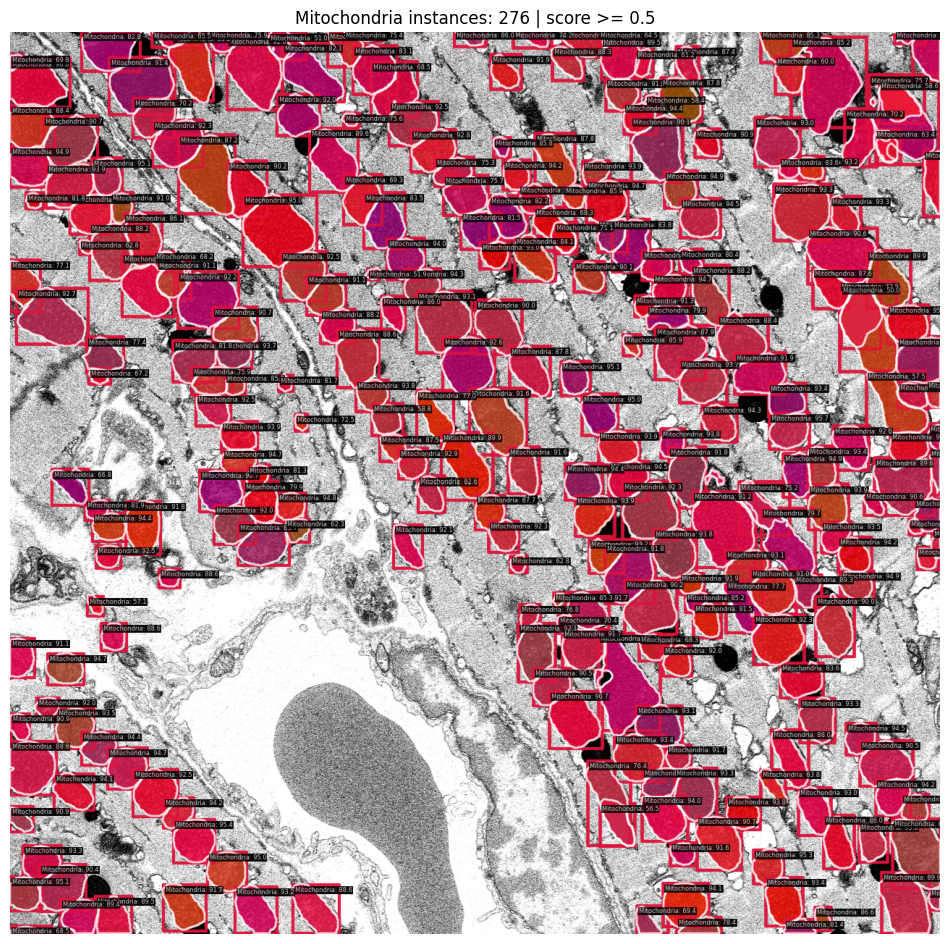

Device: cuda:0
Config: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\Mito_instance\RTM_ins.py
Checkpoint: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\Mito_instance\best_coco_bbox_mAP_75_iter_2700.pth
Image: D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_temp\EMCFsys_MitoInstanceSegDataset\image\patch_0_1.tif
Detected instances: 276
Visualization saved to: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\Mito_instance\patch_0_1_instance_prediction.png


In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import mmcv
import torch
from mmengine import Config
from mmdet.apis import inference_detector, init_detector
from mmdet.visualization import DetLocalVisualizer

# Locate the repository whether Jupyter starts in the project root or demo/.
BASE_DIR = Path.cwd().parent.resolve()
sys.path.insert(0, str(BASE_DIR))


work_dir = (BASE_DIR / "demo" / "logs" / "Mito_instance")
data_dir = (BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_MitoInstanceSegDataset")
config_path = work_dir / "RTM_ins.py"
if not config_path.is_file():
    config_path = (BASE_DIR / "src" / "thirdParty" / "mmdetection"
                   / "configs" / "rtmdet" / "RTM_Ins.py")

# Read the checkpoint selected by MMEngine; get the best bbox_mAP_75 pth.
for file in work_dir.glob("best_coco_bbox_mAP_75_iter_*.pth"):
    checkpoint_path = str(file)
    break


# Replace None with a path string to infer another large image.
image_path = None
if image_path is None:
    test_info = json.loads((data_dir / "test.json").read_text(encoding="utf-8"))
    image_path = data_dir / "image" / test_info["images"][0]["file_name"]
else:
    image_path = Path(image_path).expanduser().resolve()
if not image_path.is_file():
    raise FileNotFoundError(f"Inference image not found: {image_path}")

score_threshold = 0.5
max_instance = 400
device = "cuda:0" if torch.cuda.is_available() else "cpu"
cfg = Config.fromfile(str(config_path))
cfg.model.test_cfg.score_thr = score_threshold
cfg.model.slide_cfg.max_per_img = max_instance
model = init_detector(cfg, str(checkpoint_path), device=device)
model.dataset_meta = dict(classes=("Mitochondria",), palette=[(220, 20, 60)])

# SlidingRTMDet runs tiled inference and returns merged full-image instances.
result = inference_detector(model, str(image_path))
keep = result.pred_instances.scores >= score_threshold
result.pred_instances = result.pred_instances[keep]

# Clamp only for drawing: MMEngine requires coordinates strictly inside image.
height, width = result.metainfo["ori_shape"][:2]
result.pred_instances.bboxes[:, 0::2].clamp_(0, width - 1)
result.pred_instances.bboxes[:, 1::2].clamp_(0, height - 1)

image = mmcv.imread(str(image_path), channel_order="rgb")
output_path = work_dir / f"{image_path.stem}_instance_prediction.png"
visualizer = DetLocalVisualizer(name="mitochondria_inference")
visualizer.dataset_meta = model.dataset_meta
visualizer.add_datasample(
    name=image_path.stem,
    image=image,
    data_sample=result,
    draw_gt=False,
    draw_pred=True,
    show=False,
    out_file=str(output_path),
    pred_score_thr=score_threshold,
)
rendered = visualizer.get_image()

plt.figure(figsize=(12, 12))
plt.imshow(rendered)
plt.title(f"Mitochondria instances: {len(result.pred_instances)} | score >= {score_threshold}")
plt.axis("off")
plt.show()

print(f"Device: {device}")
print(f"Config: {config_path}")
print(f"Checkpoint: {checkpoint_path}")
print(f"Image: {image_path}")
print(f"Detected instances: {len(result.pred_instances)}")
print(f"Visualization saved to: {output_path}")


Get Test coco result

In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import mmcv
import torch
from mmengine import Config
from mmdet.apis import inference_detector, init_detector
from mmdet.visualization import DetLocalVisualizer

# Locate the repository whether Jupyter starts in the project root or demo/.
BASE_DIR = Path.cwd().parent.resolve()
sys.path.insert(0, str(BASE_DIR))

work_dir = (BASE_DIR / "demo" / "logs" / "Mito_instance")
data_dir = (BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_MitoInstanceSegDataset")
config_path = (work_dir / "RTM_ins.py")

if not config_path.is_file():
    config_path = (BASE_DIR / "src" / "thirdParty" / "mmdetection" / "configs" / "rtmdet" / "RTM_Ins.py")

# Read the checkpoint selected by MMEngine; get the best bbox_mAP_75 pth.
for file in work_dir.glob("best_coco_bbox_mAP_75_iter_*.pth"):
    checkpoint_path = str(file)
    break


cfg = Config.fromfile(str(config_path))
test_json = (data_dir / "test.json").resolve()
cfg.test_dataloader.dataset.data_root = str(data_dir)
cfg.test_dataloader.dataset.ann_file = str(test_json)
cfg.test_dataloader.dataset.data_prefix = dict(img="image/")
cfg.test_dataloader.num_workers = 0
cfg.test_dataloader.persistent_workers = False
# DataLoader and CocoMetric must use the same COCO annotation file.
cfg.test_evaluator.ann_file = str(test_json)
cfg.test_evaluator.proposal_nums = (300, 400, 500)
cfg.model.slide_cfg.max_per_img = max(cfg.test_evaluator.proposal_nums)
if Path(cfg.test_dataloader.dataset.ann_file).resolve() != Path(cfg.test_evaluator.ann_file).resolve():
    raise ValueError("The test dataset and CocoMetric must use the same annotation file.")
cfg.load_from = str(checkpoint_path)
cfg.work_dir = str(work_dir.resolve())

print(f"Test annotations: {cfg.test_evaluator.ann_file}")
print(f"COCO maxDets: {cfg.test_evaluator.proposal_nums}")
print(f"Full-image prediction limit: {cfg.model.slide_cfg.max_per_img}")
runner = Runner.from_cfg(cfg)
test_metrics = runner.test()
print(test_metrics)


Test annotations: D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_temp\EMCFsys_MitoInstanceSegDataset\test.json
COCO maxDets: (300, 400, 500)
Full-image prediction limit: 500
09/27 00:38:34 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.11.10 | packaged by Anaconda, Inc. | (main, Oct  3 2024, 07:22:26) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1062266660
    GPU 0: NVIDIA GeForce RTX 3090
    CUDA_HOME: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8
    NVCC: Cuda compilation tools, release 11.8, V11.8.89
    MSVC: n/a, reason: fileno
    PyTorch: 2.5.1+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 201703
  - MSVC 192930154
  - Intel(R) oneAPI Math Kernel Library Version 2024.2.2-Product Build 20240823 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.5.3 (Git Hash 66f0cb9eb66affd2da3b

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


09/27 00:38:37 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
09/27 00:38:37 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(49          ) EMAHook                            
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
after_load_checkpoint:
(49          ) EMAHook                            
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(49          ) EMAHook                            
(NORMAL      ) IterTimerHook                      
(NORMAL      ) IterPipelineSwitchHook             
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHo

Use sahi to inference a big image with more than thounds instance.

Note that, train dataset was crop from q1_x01_y01_s0621.tif.
We crop 4 patch from q1_x01_y01_s0621.tif, and 2 patches for train, 1 patch for val and 1 patch for test.

So, the test data was never seen by the model when training.

In this demo, we select full-size image named "SEM Imaging_TLD-BSE_q1_x01_y01_s0197.tif" for result visualization,

which is far away from the train\val\test patches from "q1_x01_y01_s0621.tif" in the 3D data volume.

Loads checkpoint by local backend from path: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\Mito_Instance\best_coco_bbox_mAP_75_iter_2700.pth


c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\mmengine\runner\checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filename,

Performing prediction on 42 slices.


Processing slices: 100%|██████████| 42/42 [00:04<00:00,  8.65it/s]


Slicing performed in 0.027164699975401163 seconds.
Prediction performed in 3.8797011741553433 seconds.
Postprocessing performed in 0.9945626258850098 seconds.


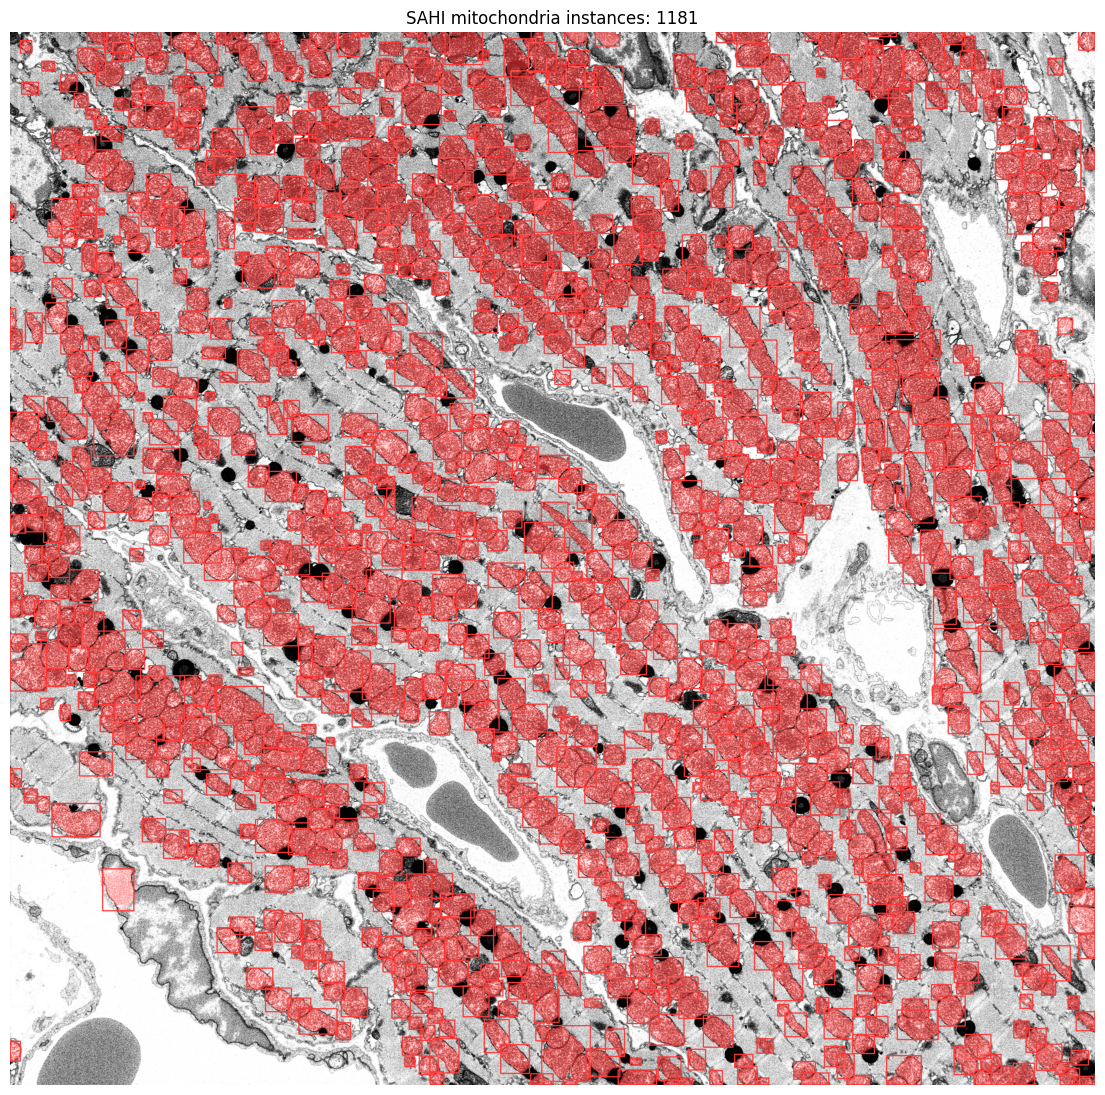

Device: cuda:0
Image: D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_temp\EMCFsys_MitoInstanceSegDataset\inference_data\SEM Imaging_TLD-BSE_q1_x01_y01_s0197.tif
Checkpoint: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\Mito_Instance\best_coco_bbox_mAP_75_iter_2700.pth
Detected instances after SAHI merge: 1181
Visualization: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\Mito_Instance\sahi_predictions\SEM Imaging_TLD-BSE_q1_x01_y01_s0197_sahi.png
COCO predictions: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\Mito_Instance\sahi_predictions\SEM Imaging_TLD-BSE_q1_x01_y01_s0197_sahi.json


In [ ]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import torch
from mmengine import Config
from PIL import Image
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

BASE_DIR = Path.cwd().resolve().parent
sys.path.insert(0, str(BASE_DIR))


work_dir = (BASE_DIR / "demo" / "logs" / "Mito_Instance")
data_dir = (BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_MitoInstanceSegDataset")

# random select a full-size image for inference and visualization
image_path = (data_dir / "inference_data" / "SEM Imaging_TLD-BSE_q1_x01_y01_s0197.tif")
# image_path = (data_dir / "inference_data" / "SEM Imaging_TLD-BSE_q1_x01_y01_s1061.tif")

if "image_path" in globals() and image_path:
    sahi_image_path = Path(image_path).expanduser().resolve()
else:
    test_info = json.loads((data_dir / "test.json").read_text(encoding="utf-8"))
    sahi_image_path = data_dir / "image" / test_info["images"][0]["file_name"]
if not sahi_image_path.is_file():
    raise FileNotFoundError(f"Inference image not found: {sahi_image_path}")

# Use the exact config/checkpoint saved by the completed training run.
trained_config = work_dir / "RTM_ins.py"
for file in work_dir.glob("best_coco_bbox_mAP_75_iter_*.pth"):
    checkpoint_path = str(file)
    break

# SAHI owns the outer slicing. Its MMDetection adapter requires a Resize step,
# so create a dedicated config using ordinary RTMDet for each 512 x 512 slice.
sahi_cfg = Config.fromfile(str(trained_config))
sahi_cfg.model.type = "RTMDet"
sahi_cfg.model.pop("slide_cfg", None)
sahi_cfg.model.test_cfg.score_thr = 0.5
sahi_cfg.model.test_cfg.max_per_img = 100
sahi_pipeline = [
    dict(type="LoadImageFromFile", backend_args=None),
    dict(type="Resize", scale=(512, 512), keep_ratio=False),
    dict(type="PackDetInputs",
         meta_keys=("img_path", "ori_shape", "img_shape", "scale_factor")),
]
sahi_cfg.test_dataloader.dataset.pipeline = sahi_pipeline
sahi_config_path = work_dir / "RTM_ins_sahi_inference.py"
sahi_cfg.dump(str(sahi_config_path))

score_threshold = 0.65
device = "cuda:0" if torch.cuda.is_available() else "cpu"
detection_model = AutoDetectionModel.from_pretrained(
    model_type="mmdet",
    model_path=str(checkpoint_path),
    config_path=str(sahi_config_path),
    confidence_threshold=score_threshold,
    mask_threshold=0.5,
    category_mapping={"0": "Mitochondria"},
    device=device,
    image_size=512,
)

prediction_result = get_sliced_prediction(
    image=str(sahi_image_path),
    detection_model=detection_model,
    slice_height=512,
    slice_width=512,
    overlap_height_ratio=0.22,
    overlap_width_ratio=0.22,
    perform_standard_pred=False,
    postprocess_type="GREEDYNMM",
    postprocess_match_metric="IOS",
    postprocess_match_threshold=0.5,
    postprocess_class_agnostic=False,
    merge_buffer_length=1000,
    progress_bar=True,
    verbose=2,
)

output_dir = work_dir / "sahi_predictions"
output_dir.mkdir(parents=True, exist_ok=True)
output_stem = f"{sahi_image_path.stem}_sahi"
prediction_result.export_visuals(
    export_dir=str(output_dir),
    file_name=output_stem,
    rect_th=2,
    text_size=0.5,
    hide_labels=True,
    hide_conf=True,
)
visual_path = output_dir / f"{output_stem}.png"
json_path = output_dir / f"{output_stem}.json"
with json_path.open("w", encoding="utf-8") as handle:
    json.dump(prediction_result.to_coco_predictions(image_id=1), handle)

with Image.open(visual_path) as visual_image:
    plt.figure(figsize=(14, 14))
    plt.imshow(visual_image)
    plt.title(f"SAHI mitochondria instances: {len(prediction_result.object_prediction_list)}")
    plt.axis("off")
    plt.show()

print(f"Device: {device}")
print(f"Image: {sahi_image_path}")
print(f"Checkpoint: {checkpoint_path}")
print(f"Detected instances after SAHI merge: {len(prediction_result.object_prediction_list)}")
print(f"Visualization: {visual_path}")
print(f"COCO predictions: {json_path}")


#  Inference in 3D Volume 

And, we can run from "q1_x01_y01_s0008.tif" to "q1_x01_y01_s1099.tif" for 3D volume reconstruction. 

Then the results can be sent to Amira3D\Arivis Pro for 3D rendering.

In [ ]:
# download the 3D volume from huggingface dataset (about 6 GB, with about 1000 slices)
# Zeyu0102/Mouse_mito_volume_EM 

import os
from huggingface_hub import snapshot_download
from pathlib import Path


current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents)
     if (path / "demo" / "Instance_Mito_seg.ipynb").is_file()),
    None,
)

if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")


local_dir = project_root / "demo" / "datasets_temp" / "EMCFsys_MitoInstanceSegDataset" / "volume"
snapshot_download(repo_id="Zeyu0102/Mouse_mito_volume_EM", repo_type="dataset",
                  local_dir=local_dir,
                  local_dir_use_symlinks=False, 
                  resume_download=True,
                  )

print("Mouse_mito_volume_EM 3D Reconstruction Dataset downloaded successfully.")

Then we can inference all image, and output masks and colored instance visualization.

We set the score_threshold as 0.5 in this demo.

Set the max instances as 100 in a [512, 512] window.

In [ ]:
from pathlib import Path
import gc
import json
import time

import cv2
import numpy as np
import torch
from mmengine import Config
from PIL import Image
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

# Batch SAHI inference for a TIFF volume.
current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents)
     if (path / "demo" / "Instance_Mito_seg.ipynb").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")
work_dir = project_root / "demo" / "logs"
data_dir = project_root / "demo" / "datasets_temp" / "EMCFsys_MitoInstanceSegDataset"
volume_dir = data_dir / "volume"
visualization_dir = data_dir / "volume_sahi_visualizations"
mask_dir = data_dir / "volume_sahi_masks"
visualization_dir.mkdir(parents=True, exist_ok=True)
mask_dir.mkdir(parents=True, exist_ok=True)

tif_paths = sorted(
    path for path in volume_dir.iterdir()
    if path.is_file() and path.suffix.lower() in {".tif", ".tiff"}
)
if not tif_paths:
    raise FileNotFoundError(f"No TIFF images found in {volume_dir}")
max_images = None  # Set to an integer (for example 1) for a quick trial run.
if max_images is not None:
    tif_paths = tif_paths[:max_images]
skip_existing = True

# Build one SAHI-compatible RTMDet model and reuse it for the whole sequence.
trained_config = work_dir / "RTM_ins.py"
last_checkpoint = work_dir / "last_checkpoint"
if last_checkpoint.is_file():
    checkpoint_path = Path(last_checkpoint.read_text(encoding="utf-8").strip()).expanduser()
    if not checkpoint_path.is_absolute():
        checkpoint_path = work_dir / checkpoint_path
else:
    checkpoints = sorted(work_dir.glob("iter_*.pth"), key=lambda path: path.stat().st_mtime)
    if not checkpoints:
        raise FileNotFoundError(f"No checkpoint found under {work_dir}")
    checkpoint_path = checkpoints[-1]
for required_path in (trained_config, checkpoint_path):
    if not required_path.is_file():
        raise FileNotFoundError(required_path)

score_threshold = 0.5
sahi_cfg = Config.fromfile(str(trained_config))
sahi_cfg.model.type = "RTMDet"
sahi_cfg.model.pop("slide_cfg", None)
sahi_cfg.model.test_cfg.score_thr = score_threshold
sahi_cfg.model.test_cfg.max_per_img = 100
sahi_cfg.test_dataloader.dataset.pipeline = [
    dict(type="LoadImageFromFile", backend_args=None),
    dict(type="Resize", scale=(512, 512), keep_ratio=False),
    dict(type="PackDetInputs",
         meta_keys=("img_path", "ori_shape", "img_shape", "scale_factor")),
]
sahi_config_path = work_dir / "RTM_ins_sahi_inference.py"
sahi_cfg.dump(str(sahi_config_path))
device = "cuda:0" if torch.cuda.is_available() else "cpu"
detection_model = AutoDetectionModel.from_pretrained(
    model_type="mmdet",
    model_path=str(checkpoint_path),
    config_path=str(sahi_config_path),
    confidence_threshold=score_threshold,
    mask_threshold=0.5,
    category_mapping={"0": "Mitochondria"},
    device=device,
    image_size=512,
)

def prediction_to_instance_mask(predictions, image_shape):
    """Rasterize SAHI polygons as a uint16 instance-label image."""
    height, width = image_shape
    if len(predictions) > np.iinfo(np.uint16).max:
        raise ValueError("More instances than uint16 can represent")
    label_image = np.zeros((height, width), dtype=np.uint16)
    # Lower confidence is drawn first, so higher-confidence masks own overlaps.
    ordered = sorted(predictions, key=lambda prediction: prediction.score.value)
    for instance_id, prediction in enumerate(ordered, start=1):
        shifted = prediction.get_shifted_object_prediction()
        if shifted.mask is None:
            continue
        for polygon in shifted.mask.segmentation:
            points = np.asarray(polygon, dtype=np.float32).reshape(-1, 2)
            if len(points) < 3:
                continue
            points[:, 0] = np.clip(points[:, 0], 0, width - 1)
            points[:, 1] = np.clip(points[:, 1], 0, height - 1)
            cv2.fillPoly(label_image, [np.rint(points).astype(np.int32)], int(instance_id))
    return label_image, ordered

def make_visualization(image_path, label_image, predictions):
    """Create a fast colored-mask and bounding-box overlay for dense images."""
    with Image.open(image_path) as image_file:
        image = np.array(image_file.convert("RGB"), dtype=np.uint8)
    rng = np.random.default_rng(20260921)
    color_lut = np.zeros((len(predictions) + 1, 3), dtype=np.uint8)
    if predictions:
        color_lut[1:] = rng.integers(40, 256, size=(len(predictions), 3), dtype=np.uint8)
    foreground = label_image > 0
    colored = color_lut[label_image]
    overlay = image.copy()
    overlay[foreground] = np.rint(
        0.55 * image[foreground] + 0.45 * colored[foreground]
    ).astype(np.uint8)
    for prediction in predictions:
        x1, y1, x2, y2 = prediction.get_shifted_object_prediction().bbox.to_xyxy()
        cv2.rectangle(
            overlay,
            (max(0, round(x1)), max(0, round(y1))),
            (min(overlay.shape[1] - 1, round(x2)),
             min(overlay.shape[0] - 1, round(y2))),
            color=(255, 40, 40),
            thickness=2,
        )
    return overlay

print(f"Device: {device}; TIFF images: {len(tif_paths)}")
print(f"Visualizations -> {visualization_dir}")
print(f"Instance masks -> {mask_dir}")
failures = []
processed = 0
for index, tif_path in enumerate(tif_paths, start=1):
    visual_path = visualization_dir / f"{tif_path.stem}.jpg"
    mask_path = mask_dir / f"{tif_path.stem}.tif"
    if skip_existing and visual_path.is_file() and mask_path.is_file():
        print(f"[{index}/{len(tif_paths)}] Skipped existing: {tif_path.name}")
        continue
    started = time.perf_counter()
    try:
        prediction_result = get_sliced_prediction(
            image=str(tif_path),
            detection_model=detection_model,
            slice_height=512,
            slice_width=512,
            overlap_height_ratio=0.22,
            overlap_width_ratio=0.22,
            perform_standard_pred=False,
            postprocess_type="GREEDYNMM",
            postprocess_match_metric="IOS",
            postprocess_match_threshold=0.5,
            postprocess_class_agnostic=False,
            merge_buffer_length=1000,
            progress_bar=False,
            verbose=0,
        )
        with Image.open(tif_path) as source_image:
            image_shape = (source_image.height, source_image.width)
        label_image, ordered_predictions = prediction_to_instance_mask(
            prediction_result.object_prediction_list, image_shape
        )
        Image.fromarray(label_image).save(mask_path, compression="tiff_lzw")
        visualization = make_visualization(tif_path, label_image, ordered_predictions)
        Image.fromarray(visualization).save(visual_path, quality=95, subsampling=0)
        processed += 1
        elapsed = time.perf_counter() - started
        print(f"[{index}/{len(tif_paths)}] {tif_path.name}: "
              f"{len(ordered_predictions)} instances, {elapsed:.1f} s")
        del prediction_result, label_image, visualization, ordered_predictions
        gc.collect()
    except Exception as exc:
        failures.append((tif_path.name, str(exc)))
        print(f"[{index}/{len(tif_paths)}] Failed {tif_path.name}: {exc}")

print(f"Completed {processed} new images; failures: {len(failures)}")
if failures:
    for name, error in failures:
        print(f"  {name}: {error}")
    raise RuntimeError(f"SAHI inference failed for {len(failures)} images")


# Train ViT-Adapter - RTM 

We also set the ViT-adapter with Pretrained EMCFsys parameters. 

In [ ]:
from pathlib import Path
from mmengine import Config
from mmengine.runner import Runner
import sys

BASE_DIR = Path.cwd().parent.resolve()
sys.path.insert(0, str(BASE_DIR))
print(BASE_DIR)
# src\thirdParty\mmdetection\configs\rtmdet\ViTAdapter_RTM_Ins.py
cfg_path = (BASE_DIR / "src" / "thirdParty" / "mmdetection" / "configs" / "rtmdet" / "ViTAdapter_RTM_Ins.py")
pretrained_model = (BASE_DIR / "models" / "EMCellFound_Adapter_mmbackend.pth")
work_dir = (BASE_DIR / "demo" / "logs" / "Mito_Instance_ViTAdapter")


cfg = Config.fromfile(str(cfg_path))
json_dir = (BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_MitoInstanceSegDataset")

cfg.data_root = str(json_dir)
for split, loader in (
    ("train", cfg.train_dataloader),
    ("val", cfg.val_dataloader),
    ("test", cfg.test_dataloader),
):
    loader.dataset.data_root = str(json_dir)
    loader.dataset.ann_file = f"{split}.json"

cfg.val_evaluator.ann_file = str(json_dir / "val.json")
cfg.val_evaluator.proposal_nums = (400, 700, 1000)
cfg.val_evaluator.use_dense_max_dets = True
cfg.model.slide_cfg.max_per_img = max(cfg.val_evaluator.proposal_nums)
cfg.test_evaluator.ann_file = str(json_dir / "test.json")

# If setting load_from as None, model will init from scratch
cfg.load_from = str(pretrained_model.resolve())
cfg.work_dir = str(work_dir.resolve())

# set the batch size
cfg.train_dataloader.batch_size = 2

runner = Runner.from_cfg(cfg)
runner.train()

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\mmengine\optim\optimizer\zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \


D:\napari_EMCF\EMCFsys\emcfsys


c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


09/27 11:58:07 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.11.10 | packaged by Anaconda, Inc. | (main, Oct  3 2024, 07:22:26) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 206069917
    GPU 0: NVIDIA GeForce RTX 3090
    CUDA_HOME: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8
    NVCC: Cuda compilation tools, release 11.8, V11.8.89
    MSVC: n/a, reason: fileno
    PyTorch: 2.5.1+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 201703
  - MSVC 192930154
  - Intel(R) oneAPI Math Kernel Library Version 2024.2.2-Product Build 20240823 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.5.3 (Git Hash 66f0cb9eb66affd2da3bf5f8d897376f04aae6af)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX512
  - CUDA Runtime 11.8
  - NVCC architecture flags: -ge

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\mmengine\runner\checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filename,

The model and loaded state dict do not match exactly

unexpected key in source state_dict: classifier.weight, classifier.bias, decoder.mask_token, decoder.decoder_pos_embed, decoder.decoder_embed.weight, decoder.decoder_embed.bias, decoder.decoder_blocks.0.norm1.weight, decoder.decoder_blocks.0.norm1.bias, decoder.decoder_blocks.0.attn.qkv.weight, decoder.decoder_blocks.0.attn.qkv.bias, decoder.decoder_blocks.0.attn.proj.weight, decoder.decoder_blocks.0.attn.proj.bias, decoder.decoder_blocks.0.norm2.weight, decoder.decoder_blocks.0.norm2.bias, decoder.decoder_blocks.0.mlp.fc1.weight, decoder.decoder_blocks.0.mlp.fc1.bias, decoder.decoder_blocks.0.mlp.fc2.weight, decoder.decoder_blocks.0.mlp.fc2.bias, decoder.decoder_blocks.1.norm1.weight, decoder.decoder_blocks.1.norm1.bias, decoder.decoder_blocks.1.attn.qkv.weight, decoder.decoder_blocks.1.attn.qkv.bias, decoder.decoder_blocks.1.attn.proj.weight, decoder.decoder_blocks.1.attn.proj.bias, decoder.decoder_blocks.1.norm2.weight, decoder.d

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


09/27 11:58:18 - mmengine - INFO - Exp name: ViTAdapter_RTM_Ins_20260927_115805
09/27 11:58:18 - mmengine - INFO - Iter(train) [   1/3000]  base_lr: 1.0000e-09 lr: 1.0000e-10  eta: 2:33:12  time: 3.0653  data_time: 1.6121  memory: 6014  grad_norm: 32.8861  loss: 4.1291  loss_cls: 1.0736  loss_bbox: 1.1211  loss_mask: 1.9343
09/27 11:58:46 - mmengine - INFO - Iter(train) [  20/3000]  base_lr: 6.3555e-06 lr: 6.3555e-07  eta: 1:16:53  time: 1.5480  data_time: 1.0651  memory: 7357  grad_norm: 48.9194  loss: 4.1008  loss_cls: 1.0592  loss_bbox: 1.1137  loss_mask: 1.9280
